MACHINE LEARNING
Seminar 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import io
import random
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Part I: Data preparation & analysis

In [16]:
df = pd.read_csv('Train_skelletonpoints.csv', sep=',', header=None)
display(df.head(10))

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,136.03,198.72,194.99,241.76,201.30,202.46,278.33,351.28,351.28,458.27,...,0.68862,0.78250,0.68072,0.62456,0.68884,0.77941,0.83174,0.840540,0.79928,0.667820
1,202.42,259.99,255.88,313.45,297.00,264.10,317.56,387.46,383.35,473.81,...,0.60709,0.82400,0.75419,0.65880,0.80821,0.77518,0.86345,0.876270,0.62875,0.629860
2,193.42,250.56,254.64,340.35,397.49,246.48,319.94,270.97,401.57,479.12,...,0.31261,0.57599,0.68195,0.25706,0.27761,0.26193,0.95407,0.128050,0.89682,0.008460
3,205.81,257.79,255.71,301.45,268.18,259.87,313.92,388.78,380.46,471.95,...,0.75569,0.89123,0.70243,0.65057,0.72541,0.75135,0.78706,0.774260,0.63834,0.717970
4,289.49,303.86,300.27,354.16,415.24,307.46,354.16,404.46,364.94,451.17,...,0.43415,0.59738,0.66353,0.51422,0.79301,0.73571,0.67160,0.323880,0.78987,0.008824
5,360.70,316.07,317.72,354.08,423.50,314.42,354.08,416.89,340.86,459.87,...,0.56845,0.61904,0.60180,0.31584,0.39940,0.18240,0.87548,0.023613,0.89182,0.008884
6,164.20,221.80,221.80,301.54,332.56,221.80,292.68,323.70,354.71,452.18,...,0.76418,0.75357,0.76965,0.68287,0.85687,0.93174,0.89225,0.878170,0.62280,0.758890
7,180.35,223.35,220.99,302.26,266.26,225.70,272.54,270.64,399.34,473.61,...,0.48707,0.60230,0.66747,0.37093,0.41956,0.39981,0.84413,0.059907,0.75432,0.013039
8,163.96,229.23,229.23,294.50,264.04,229.23,298.85,364.12,385.88,477.26,...,0.54529,0.63186,0.74941,0.49792,0.60808,0.86344,0.84678,0.862390,0.60577,0.793990
9,126.02,181.95,179.52,233.01,198.97,184.38,267.05,330.27,325.40,437.25,...,0.72584,0.78501,0.77104,0.70588,0.69363,0.86506,0.75568,0.836190,0.50147,0.568340


Create a function/script that takes SkelletonPoints as input and plots the corresponding pose. Your plotting function should also display the label associated with the pose being plotted.

In [21]:
print(df.iloc[0:2].values)

[[1.3603e+02 1.9872e+02 1.9499e+02 2.4176e+02 2.0130e+02 2.0246e+02
  2.7833e+02 3.5128e+02 3.5128e+02 4.5827e+02 5.6526e+02 3.5614e+02
  4.5827e+02 5.5554e+02 1.2469e+02 1.2620e+02 1.3792e+02 1.4050e+02
  2.2430e+02 2.2111e+02 2.8305e+02 3.4968e+02 2.8804e+02 1.5917e+02
  1.2821e+02 1.4280e+02 2.5465e+02 2.4979e+02 2.5952e+02 1.8657e+02
  1.6711e+02 1.7198e+02 2.3698e+02 2.0880e+02 2.5767e+02 1.9100e+02
  8.9233e-01 6.6412e-01 6.4404e-01 7.6874e-01 7.3817e-01 6.8419e-01
  8.7514e-01 8.8166e-01 6.8862e-01 7.8250e-01 6.8072e-01 6.2456e-01
  6.8884e-01 7.7941e-01 8.3174e-01 8.4054e-01 7.9928e-01 6.6782e-01]
 [2.0242e+02 2.5999e+02 2.5588e+02 3.1345e+02 2.9700e+02 2.6410e+02
  3.1756e+02 3.8746e+02 3.8335e+02 4.7381e+02 5.6016e+02 3.8746e+02
  4.7381e+02 5.6016e+02 1.9420e+02 1.9420e+02 2.0653e+02 2.0653e+02
  2.5328e+02 2.4300e+02 2.9851e+02 3.4785e+02 3.0673e+02 1.8749e+02
  1.6281e+02 1.5870e+02 2.7795e+02 2.7384e+02 2.7795e+02 2.1627e+02
  2.2861e+02 2.3683e+02 2.6561e+02 2.4094e+02 2

In [11]:
def plot_pose(Skpoints):
    x_points = []
    y_points = []
    for i in range(18):
        x_points.append(Skpoints[i])
        y_points.append(Skpoints[18+i])

    plt.plot(x_points, y_points, marker='o', linestyle='-')
    plt.xlabel('X points')
    plt.ylabel('Y points')
    plt.title('Pose')
    plt.grid(True)
    plt.show()

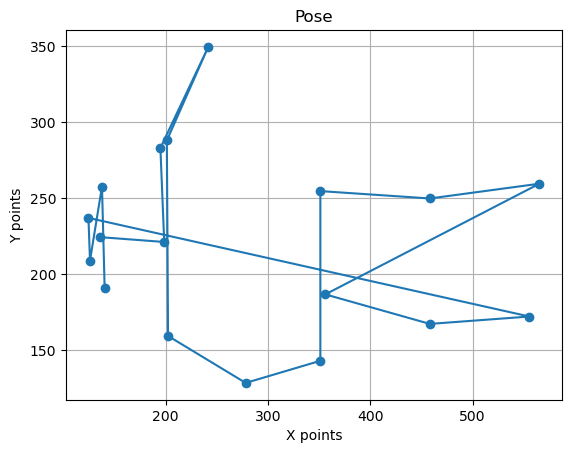

In [19]:
plot_pose(df.iloc[0])